# Task 1

scrape information from the https://en.wikipedia.org/wiki/List_of_Panchayat_episodes


## install necessary modules

In [ ]:
! pip install requests beautifulsoup4
! pip install nltk wordcloud

## Mount the drive and set the working directory

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

import os

os.chdir('/content/drive/My Drive/GU/hw1/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


## Start scraping data from wikipedia page using requests and BeautiulSoup

In [ ]:
# import the necessary modules
import requests
from bs4 import BeautifulSoup
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk
import re
import matplotlib.pyplot as plt

from collections import Counter
import string
import pandas as pd

In [ ]:
# get the stopwords from NLTK
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Browser's Developer Tool -> inspect element -> style class of desired table??

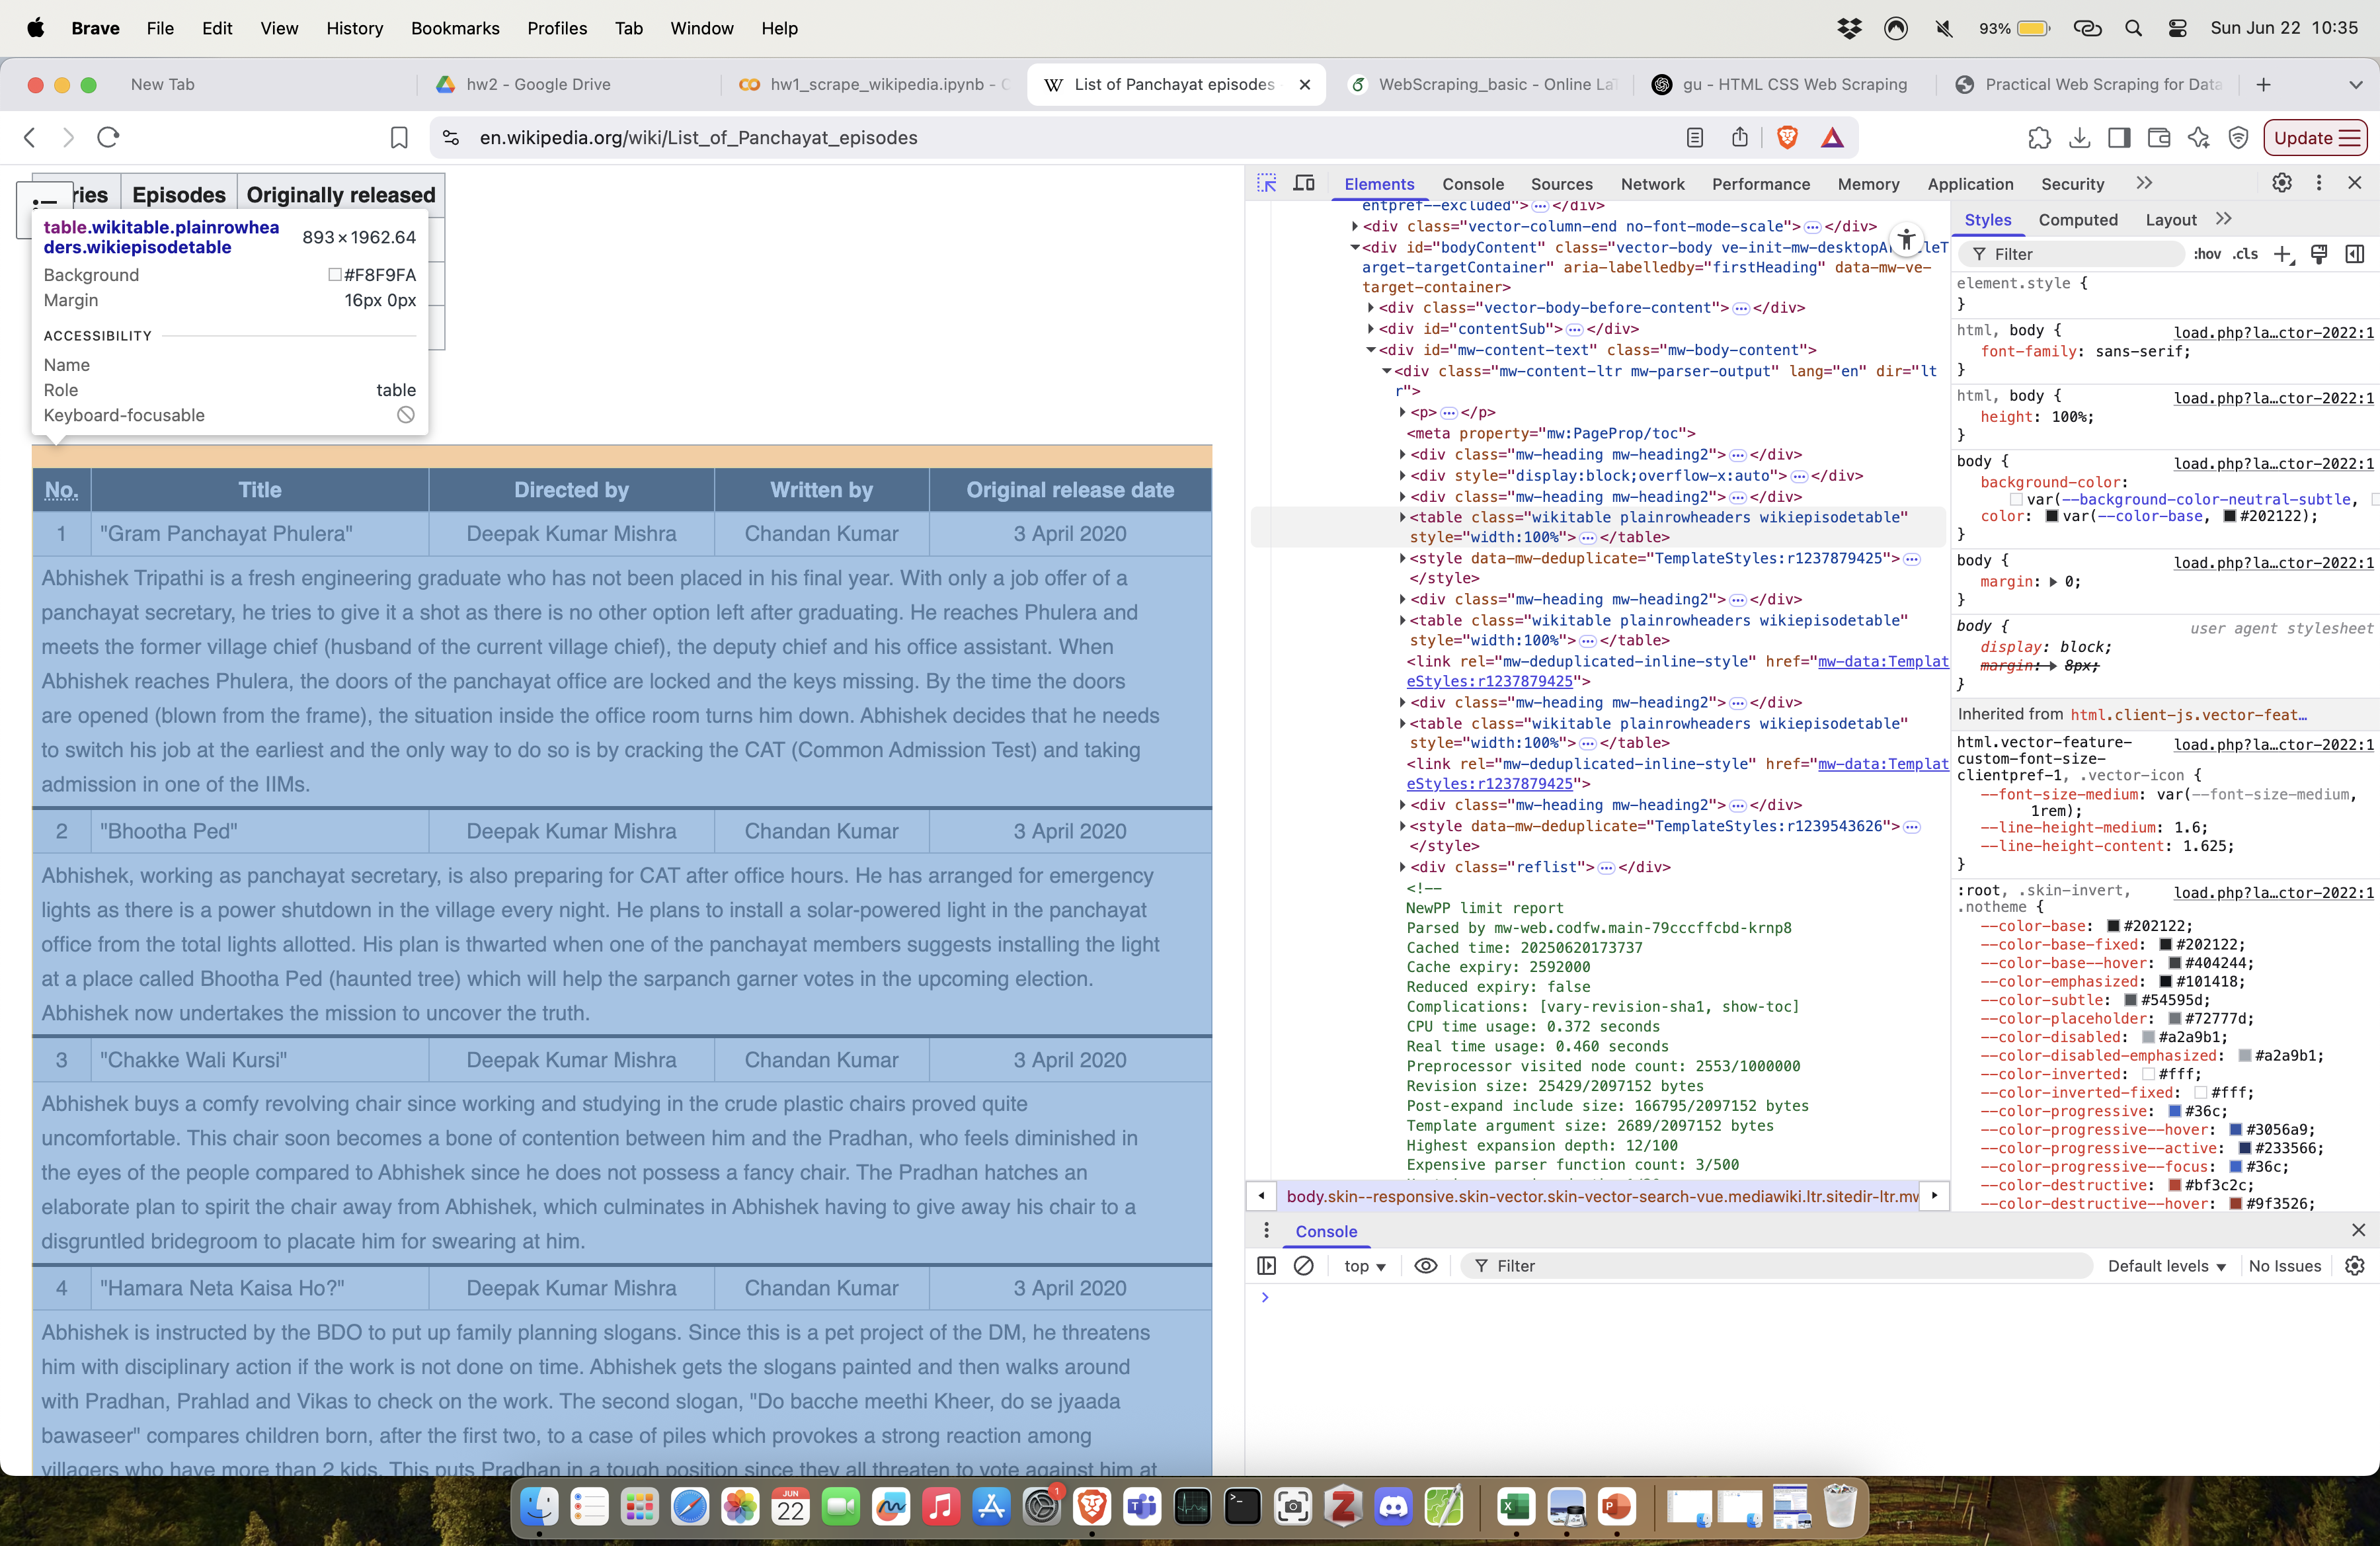

can we use any of the following?

```
soup.find_all('table', class_='wikiepisodetable')  

soup.find_all('table', class_='wikitable plainrowheaders wikiepisodetable')

soup.find_all('table', attrs={'class': ['wikitable', 'wikiepisodetable']})

```

In [ ]:
# Define our functions here
def save_episode_data( html_soup):

    episodes = []
    #ep_tables = html_soup.find_all('table', class_='wikiepisodetable')
    ep_tables = html_soup.find_all('table', class_='wikitable plainrowheaders wikiepisodetable')

    for table in ep_tables:
        headers = []
        rows = table.find_all('tr')
    # Start by fetching the header cells from the first row to determine
    # the field names
        for header in table.find('tr').find_all('th'):
            headers.append(header.text)
    # print(headers)
    # Then go through all the rows except the first one
        for row in table.find_all('tr')[1:]:
            values = []
            # And get the column cells, the first one being inside a th-tag
            for col in row.find_all(['th','td']):
                values.append(col.text)
            if values:
                episode_dict = {}
                for i in range(len(values)):
                  episode_dict[headers[i]]= values[i]
                episodes.append(episode_dict)

    return episodes


# display word cloud from text
def print_wordcloud(str_text):

    wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(str_text)
    # now display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

    return

# function to extract specific field values
def get_field_episodes(field_name, episodes):
    str_text = ''
    list_values = [(dd.get(field_name, 'N/A')) for dd in episodes]
    for tt in list_values:
        if tt != 'N/A':
            str_text += tt + ' '
    return str_text

#load saved file
def read_html_file(file_path):
    try:
        with open(file_path, "r", encoding="utf-8") as file:
            html_content = file.read()
        return html_content
    except FileNotFoundError:
        print(f"File '{file_path}' not found.")
        return None


# read the text from the HTML content
def extract_text_from_html(html_content):

    soup = BeautifulSoup(html_content, 'html.parser')
    soup_text = soup.get_text()

    return soup_text


# Now, clean the text by removing stopwords and special characters
def clean_text(text):

    # remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()  # change to lowercase

    # tokenize the text and remove stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words and len(word) > 2]

    # finally, join the filtered words back into a single string
    filtered_text = " ".join(filtered_words)

    return filtered_text






def get_top_n_words(text, n=10):
    # Convert text to lowercase and remove punctuation
    text = text.lower().translate(str.maketrans('', '', string.punctuation))

    # Tokenize the text into words
    words = text.split()

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in words if word not in stop_words]

    # Count word frequencies
    word_freq = Counter(filtered_words)

    # Return the top N most common words
    return word_freq.most_common(n)


Lets do the webscraping and processing the data

In [ ]:
#1. scrape the URL and save the html contents
url = "https://en.wikipedia.org/wiki/List_of_Panchayat_episodes"
response = requests.get(url)
if response.status_code != 200:
    exit()


html_contents = response.text
# save the html page contents
with open("panchyat_episodes.html", "w", encoding="utf-8") as file:
    file.write(html_contents)
print("HTML Page's content saved locally to 'panchyat_episodes.html'.")


html_soup = BeautifulSoup(html_contents, 'html.parser')

# Storing the episode list
episodes = save_episode_data( html_soup)

# Show the results

for i in range(len(episodes)):
    print(episodes[i])
    break # if we want to print all data then comment this line

HTML Page's content saved locally to 'panchyat_episodes.html'.
{'No.': '1', 'Title': '"Gram Panchayat Phulera"', 'Directed by': 'Deepak Kumar Mishra', 'Written by': 'Chandan Kumar', 'Original release date': '3\xa0April\xa02020\xa0(2020-04-03)'}


## Using pickle to dump the data in 'episodes'

In [ ]:
import pickle
# Filepath to save the pickle file
pickle_file = "panchyat_episodes.pkl"

# Save the `episodes` list to a pickle file
with open(pickle_file, "wb") as file:
    pickle.dump(episodes, file)

pickle_file

'panchyat_episodes.pkl'

## Loding the 'episodes' back

In [ ]:
# Step 3: Loading Variables
loaded_episodes = None

# Open the file in binary mode
with open(pickle_file, 'rb') as file:
    # Deserialize and retrieve the variable from the file
    loaded_episodes = pickle.load(file)

print("The variable 'data' has been loaded successfully.")

print("Loaded Data:", loaded_episodes)

The variable 'data' has been loaded successfully.
Loaded Data: [{'No.': '1', 'Title': '"Gram Panchayat Phulera"', 'Directed by': 'Deepak Kumar Mishra', 'Written by': 'Chandan Kumar', 'Original release date': '3\xa0April\xa02020\xa0(2020-04-03)'}, {'No.': '\n\nAbhishek Tripathi is a fresh engineering graduate who has not been placed in his final year. With only a job offer of a panchayat secretary, he tries to give it a shot as there is no other option left after graduating. He reaches Phulera and meets the former village chief (husband of the current village chief), the deputy chief and his office assistant. When Abhishek reaches Phulera, the doors of the panchayat office are locked and the keys missing. By the time the doors are opened (blown from the frame), the situation inside the office room turns him down. Abhishek decides that he needs to switch his job at the earliest and the only way to do so is by cracking the CAT (Common Admission Test) and taking admission in one of the IIM

In [ ]:
# lets display some loaded data
loaded_episodes[:1]

[{'No.': '1',
  'Title': '"Gram Panchayat Phulera"',
  'Directed by': 'Deepak Kumar Mishra',
  'Written by': 'Chandan Kumar',
  'Original release date': '3\xa0April\xa02020\xa0(2020-04-03)'}]

In [83]:
# lets display some loaded data
loaded_episodes[:2]

[{'No.': '1',
  'Title': '"Gram Panchayat Phulera"',
  'Directed by': 'Deepak Kumar Mishra',
  'Written by': 'Chandan Kumar',
  'Original release date': '3\xa0April\xa02020\xa0(2020-04-03)'},
 {'No.': '\n\nAbhishek Tripathi is a fresh engineering graduate who has not been placed in his final year. With only a job offer of a panchayat secretary, he tries to give it a shot as there is no other option left after graduating. He reaches Phulera and meets the former village chief (husband of the current village chief), the deputy chief and his office assistant. When Abhishek reaches Phulera, the doors of the panchayat office are locked and the keys missing. By the time the doors are opened (blown from the frame), the situation inside the office room turns him down. Abhishek decides that he needs to switch his job at the earliest and the only way to do so is by cracking the CAT (Common Admission Test) and taking admission in one of the IIMs.'}]

In [ ]:
# lets display some loaded data
loaded_episodes[:4]

[{'No.': '1',
  'Title': '"Gram Panchayat Phulera"',
  'Directed by': 'Deepak Kumar Mishra',
  'Written by': 'Chandan Kumar',
  'Original release date': '3\xa0April\xa02020\xa0(2020-04-03)'},
 {'No.': '\n\nAbhishek Tripathi is a fresh engineering graduate who has not been placed in his final year. With only a job offer of a panchayat secretary, he tries to give it a shot as there is no other option left after graduating. He reaches Phulera and meets the former village chief (husband of the current village chief), the deputy chief and his office assistant. When Abhishek reaches Phulera, the doors of the panchayat office are locked and the keys missing. By the time the doors are opened (blown from the frame), the situation inside the office room turns him down. Abhishek decides that he needs to switch his job at the earliest and the only way to do so is by cracking the CAT (Common Admission Test) and taking admission in one of the IIMs.'},
 {'No.': '2',
  'Title': '"Bhootha Ped"',
  'Dir

## Lets display the wordclouds

In [ ]:
str_titles = get_field_episodes('Title', loaded_episodes)
str_desc = get_field_episodes('No.', loaded_episodes) # check if this filed can get the descriptions!!!


Wordclouds of Titles only


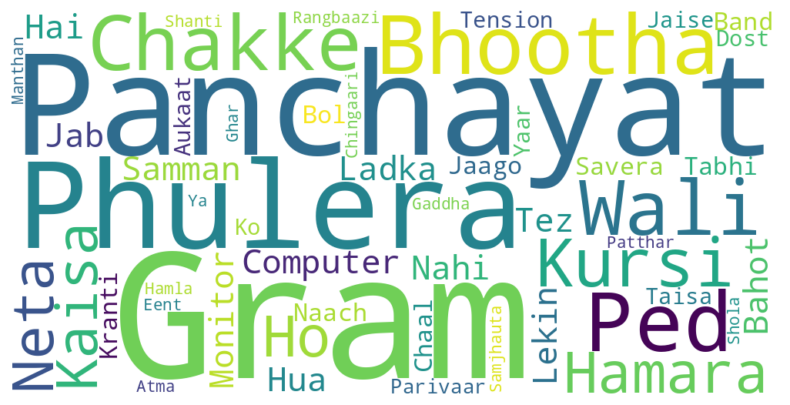

In [ ]:


print ("Wordclouds of Titles only")
print_wordcloud(str_titles)



Wordclouds of Description 


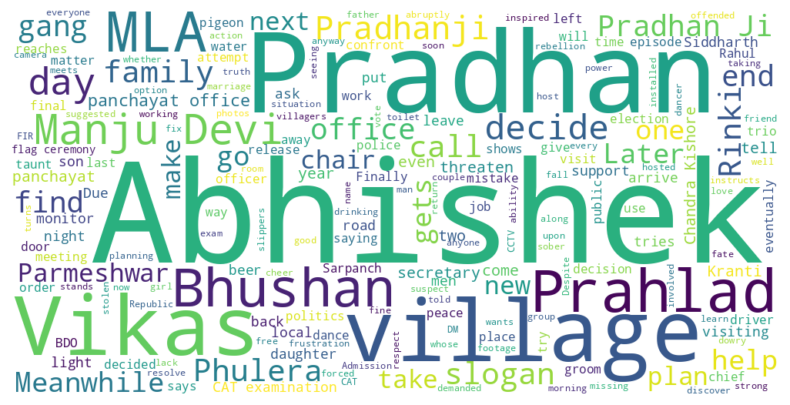

In [ ]:
print ("Wordclouds of Description ")
print_wordcloud(str_desc)


Wordclouds of Titles and Description


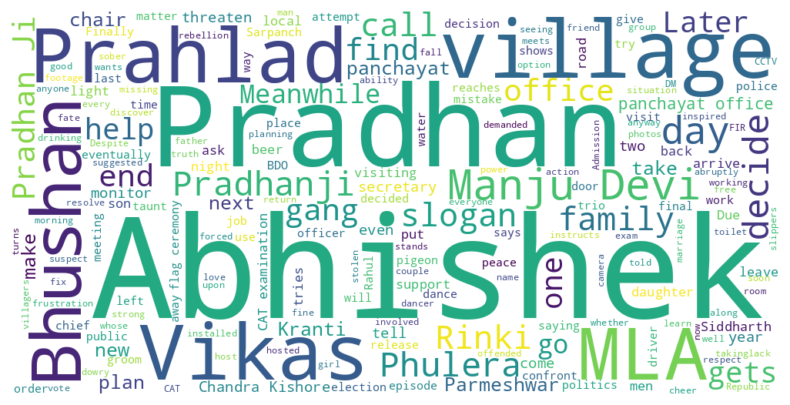

In [ ]:

print ("Wordclouds of Titles and Description")
print_wordcloud(str_titles +' '+ str_desc)

In [ ]:

# Convert  list of dictionaries (loaded_episodes) into a pandas DataFrame.
# Parameters: episodloaded_episodeses (list): List of dictionaries, where each dictionary is an episode with fields.

df_episode= pd.DataFrame(loaded_episodes)
df_episode.head()

,No.,Title,Directed by,Written by,Original release date
0,1,"""Gram Panchayat Phulera""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03)
1,\n\nAbhishek Tripathi is a fresh engineering g...,NaN,NaN,NaN,NaN
2,2,"""Bhootha Ped""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03)
3,"\n\nAbhishek, working as panchayat secretary, ...",NaN,NaN,NaN,NaN
4,3,"""Chakke Wali Kursi""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03)


Above, dataframe is got where the row 2 hAS  description in first column and then the other columns are empty. Similarly for row 4,6,....

Next:
- Move the content of every odd-numbered row (i.e., description) into a new column "Description" of the row just before it.


In [ ]:
import pandas as pd

def convert_to_dataframe_with_description(episodes):
    """
    Converts list of dictionaries to a cleaned DataFrame by extracting descriptions
    from alternate rows and assigning them to a new 'Description' column.

    Parameters:
        episodes (list): List of dictionaries parsed from web.

    Returns:
        pd.DataFrame: Cleaned DataFrame with descriptions properly assigned.
    """
    # Step 1: Convert to DataFrame
    df = pd.DataFrame(episodes)

    # Step 2: Reset index in case it's not default
    df.reset_index(drop=True, inplace=True)

    # Step 3: Create empty column 'Description'
    df['Description'] = None

    # Step 4: Loop through even rows and pull description from the next row (if available)
    for i in range(0, len(df), 2):
        if i+1 < len(df) and pd.isna(df.iloc[i+1, 1]):  # Assuming 1st col of description row is not numeric
            df.at[i, 'Description'] = str(df.iloc[i+1, 0]).strip()

    # Step 5: Drop the odd-numbered rows (1, 3, 5, ...) containing only descriptions
    df_cleaned = df.drop(index=[i for i in range(1, len(df), 2)])

    # Step 6: Reset index
    df_cleaned.reset_index(drop=True, inplace=True)

    return df_cleaned
df_episode = convert_to_dataframe_with_description(loaded_episodes)
df_episode.head()

,No.,Title,Directed by,Written by,Original release date,Description
0,1,"""Gram Panchayat Phulera""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03),Abhishek Tripathi is a fresh engineering gradu...
1,2,"""Bhootha Ped""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03),"Abhishek, working as panchayat secretary, is a..."
2,3,"""Chakke Wali Kursi""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03),Abhishek buys a comfy revolving chair since wo...
3,4,"""Hamara Neta Kaisa Ho?""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03),Abhishek is instructed by the BDO to put up fa...
4,5,"""Computer Nahi Monitor""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03),Frustrated by the lack of nightlife in the vil...


In [ ]:
df_episode.to_csv('panchyat_episode.csv', index=False)

Word Cloud from entire html text


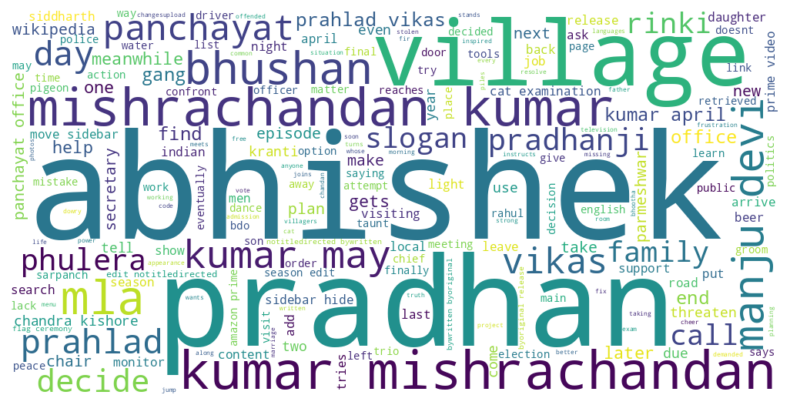

In [ ]:
# laod the saved HTML content from 'panchyat_episodes.html'

# Step 1: Read the HTML file
saved_file ='panchyat_episodes.html'
html_content = read_html_file(saved_file)
text = extract_text_from_html(html_content)
cleaned_text = clean_text(text)

print ("Word Cloud from entire html text")
print_wordcloud(cleaned_text)



In [ ]:

print ("Most frequent 5 words")
top_5_words = get_top_n_words(cleaned_text, n=5)
print(top_5_words)


print ("Most frequent 10 words")
top_10_words = get_top_n_words(cleaned_text, n=10)
print(top_10_words)

Most frequent 5 words
[('abhishek', 74), ('kumar', 52), ('pradhan', 50), ('village', 26), ('mishrachandan', 24)]
Most frequent 10 words
[('abhishek', 74), ('kumar', 52), ('pradhan', 50), ('village', 26), ('mishrachandan', 24), ('vikas', 23), ('prahlad', 22), ('panchayat', 20), ('may', 19), ('manju', 17)]


# Example: Series and Datafame

## lets play with our existing dataframe


In [ ]:
df = df_episode #Both point to the same object (changes in df affect df_episode).



In [ ]:
df = df_episode.copy() # Creates a new, independent copy (safe from modifying the original).


In [ ]:
df.head()

,No.,Title,Directed by,Written by,Original release date,Description
0,1,"""Gram Panchayat Phulera""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03),Abhishek Tripathi is a fresh engineering gradu...
1,2,"""Bhootha Ped""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03),"Abhishek, working as panchayat secretary, is a..."
2,3,"""Chakke Wali Kursi""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03),Abhishek buys a comfy revolving chair since wo...
3,4,"""Hamara Neta Kaisa Ho?""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03),Abhishek is instructed by the BDO to put up fa...
4,5,"""Computer Nahi Monitor""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03),Frustrated by the lack of nightlife in the vil...


In [ ]:
df.head(2)


,No.,Title,Directed by,Written by,Original release date,Description
0,1,"""Gram Panchayat Phulera""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03),Abhishek Tripathi is a fresh engineering gradu...
1,2,"""Bhootha Ped""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03),"Abhishek, working as panchayat secretary, is a..."


In [ ]:
df.tail(3)

,No.,Title,Directed by,Written by,Original release date,Description
21,6,"""Chingaari""",Deepak Kumar Mishra,Chandan Kumar,28 May 2024 (2024-05-28),"To fix their dented image, the Pradhan gang se..."
22,7,"""Shola""",Deepak Kumar Mishra,Chandan Kumar,28 May 2024 (2024-05-28),The MLA puts out a hit on one of the village r...
23,8,"""Hamla""",Deepak Kumar Mishra,Chandan Kumar,28 May 2024 (2024-05-28),"Finally, Pradhan rallies the whole Phulera beh..."


In [ ]:
# lets remove a column
df.drop('No.', axis=1, inplace=True)


In [ ]:
# SLICING
df.loc[0:2,'Title']

,Title
0,"""Gram Panchayat Phulera"""
1,"""Bhootha Ped"""
2,"""Chakke Wali Kursi"""


In [ ]:
# SLICING
df.loc[2:5,'Description']

,Description
2,Abhishek buys a comfy revolving chair since wo...
3,Abhishek is instructed by the BDO to put up fa...
4,Frustrated by the lack of nightlife in the vil...
5,Abhishek is having his photograph taken for th...


In [ ]:
# SLICING
df.iloc[0:2,1]

,Directed by
0,Deepak Kumar Mishra
1,Deepak Kumar Mishra


In [ ]:
# SLICING
df.iloc[0:2,:]

,Title,Directed by,Written by,Original release date,Description
0,"""Gram Panchayat Phulera""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03),Abhishek Tripathi is a fresh engineering gradu...
1,"""Bhootha Ped""",Deepak Kumar Mishra,Chandan Kumar,3 April 2020 (2020-04-03),"Abhishek, working as panchayat secretary, is a..."


In [ ]:
# SLICING
df.iloc[:,0:2]

,Title,Directed by
0,"""Gram Panchayat Phulera""",Deepak Kumar Mishra
1,"""Bhootha Ped""",Deepak Kumar Mishra
2,"""Chakke Wali Kursi""",Deepak Kumar Mishra
3,"""Hamara Neta Kaisa Ho?""",Deepak Kumar Mishra
4,"""Computer Nahi Monitor""",Deepak Kumar Mishra
5,"""Bahot Hua Samman""",Deepak Kumar Mishra
6,"""Ladka Tez Hai Lekin..""",Deepak Kumar Mishra
7,"""Jab Jaago Tabhi Savera""",Deepak Kumar Mishra
8,"""Naach""",Deepak Kumar Mishra
9,"""Bol Chaal Band""",Deepak Kumar Mishra
